In [2]:
# Import required modules
import sys
sys.path.append('../src')
from signalgen.signal_generator import SignalConfig, SignalGenerator
import matplotlib.pyplot as plt
import numpy as np
# Set up matplotlib for better plots - adjusted for screen fitting
plt.rcParams['figure.figsize'] = (10, 6)  # Reduced from (15, 10) for better screen fit
plt.rcParams['font.size'] = 10  # Slightly smaller font
plt.rcParams['figure.dpi'] = 100  # Standard DPI for better display
plt.rcParams['figure.max_open_warning'] = 20  # Allow more figures

# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget

# Scenario 1: 1 main source
config_main_only = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    use_full_bandwidth=True
)

# Scenario 2: 1 main source + 1 interference
config_main_1_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[50, 400],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[30, 40],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    use_full_bandwidth=True
)

# Scenario 3: 1 main source + 2 interference
config_main_2_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=3,  # Number of sources
    frequencies=[100, 200, 300],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[85, 90, 95],  # Angles for main signal and interferences
    sir_db=[0, 0],  # Signal-to-interference ratios
    use_full_bandwidth=True
)

# Scenario 4: 1 main source + 1 multipath
config_main_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[45],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=False
)

# Scenario 5: 1 main source + 2 multipath
config_main_2_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Scenario 6: 1 main source + 1 interference + 1 multipath
config_main_1_interference_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 70],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Initialize signal generators for all scenarios
generator_main_only = SignalGenerator(config_main_only)
generator_main_1_interference = SignalGenerator(config_main_1_interference)
generator_main_2_interference = SignalGenerator(config_main_2_interference)
generator_main_1_mp = SignalGenerator(config_main_1_mp)
generator_main_2_mp = SignalGenerator(config_main_2_mp)
generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

# Generate time axis
t = generator_main_only.generate_time_axis()

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)

# Generate signals for multipath scenarios
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

# Add multipath effects to multipath scenarios
signals_main_1_mp, _ = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.bandwidth, num_multipath_components=1)
signals_main_2_mp, _ = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.bandwidth, num_multipath_components=2)
signals_main_1_interference_1_mp, _ = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.bandwidth, num_multipath_components=1)


In [3]:
signal = signals_main_1_interference
signal_config = config_main_1_interference

In [4]:
# def plot_signal_analysis(signals, t, fs, title="Signal Analysis"):
#     """
#     Plot time domain and frequency domain analysis of signals.
    
#     Args:
#         signals: Array of signals to plot (can be 1D or 2D array)
#         t: Time axis
#         fs: Sampling frequency
#         title: Plot title
#     """
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    
#     # Ensure signals is a list/array of signals
#     if isinstance(signals, np.ndarray) and signals.ndim == 1:
#         signals = [signals]
#     elif isinstance(signals, np.ndarray) and signals.ndim == 2:
#         signals = [signals[i] for i in range(signals.shape[0])]
    
#     # Time domain plot
#     for i, signal in enumerate(signals):
#         # Ensure signal length matches time axis
#         if len(signal) != len(t):
#             # Truncate or pad signal to match time axis
#             if len(signal) > len(t):
#                 signal = signal[:len(t)]
#             else:
#                 # Pad with zeros if signal is shorter
#                 padded_signal = np.zeros(len(t), dtype=signal.dtype)
#                 padded_signal[:len(signal)] = signal
#                 signal = padded_signal
        
#         label = f'Signal {i+1}' if len(signals) > 1 else 'Signal'
#         ax1.plot(t, np.real(signal), label=label)
    
#     ax1.set_xlabel('Time (s)')
#     ax1.set_ylabel('Amplitude')
#     ax1.set_title(f'{title} - Time Domain')
#     ax1.legend()
#     ax1.grid(True)
    
#     # Frequency domain plot
#     for i, signal in enumerate(signals):
#         # Ensure signal length matches time axis
#         if len(signal) != len(t):
#             if len(signal) > len(t):
#                 signal = signal[:len(t)]
#             else:
#                 padded_signal = np.zeros(len(t), dtype=signal.dtype)
#                 padded_signal[:len(signal)] = signal
#                 signal = padded_signal
        
#         # Compute FFT
#         fft = (np.fft.fft(signal))


        
#         # Plot spectrum in dB
#         label = f'Signal {i+1}' if len(signals) > 1 else 'Signal'
#         ax2.plot(20 * np.log10(np.abs(fft)), label=label)
    
#     ax2.set_xlabel('Frequency (Hz)')
#     ax2.set_ylabel('Magnitude (dB)')
#     ax2.set_title(f'{title} - Frequency Domain')
#     ax2.legend()
#     ax2.grid(True)
    
#     # Set reasonable frequency limits
#     max_freq = fs / 2  # Nyquist frequency
#     # ax2.set_xlim(-max_freq/4, max_freq/4)  # Show central portion of spectrum
    
#     plt.tight_layout()
#     plt.show()

# # Example usage with any signal
# plot_signal_analysis(signal, t, signal_config.fs, "Signal Analysis")


In [5]:
# # Plot autocorrelation and cross-correlation of the signal
# def plot_autocorrelation(signal, t, fs, title="Signal Autocorrelation"):
#     """
#     Plot the autocorrelation and cross-correlation of a signal.
    
#     Parameters:
#     signal: Input signal (can be matrix where each row is a signal)
#     t: Time vector
#     fs: Sampling frequency
#     title: Plot title
#     """
#     # Convert to numpy array and ensure 2D
#     signal_array = np.asarray(signal)
#     if signal_array.ndim == 1:
#         signal_array = signal_array.reshape(1, -1)
    
#     # Create figure with two subplots
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
    
#     # Plot autocorrelation for each signal
#     for i in range(signal_array.shape[0]):
#         signal_row = signal_array[i, :]
        
#         # Compute autocorrelation using xcorr
#         autocorr = np.correlate(signal_row, signal_row, mode='full')
        
#         # Alternative: use scipy.signal.correlate for more options
#         from scipy import signal
#         autocorr = signal.correlate(signal_row, signal_row, mode='full')
        
#         # Normalize autocorrelation
#         autocorr = autocorr / len(signal_row)
        
#         # Create time lag vector for autocorrelation
#         lags = np.arange(-len(signal_row)+1, len(signal_row)) / fs
        
#         # Plot autocorrelation
#         label = f'Signal {i+1}' if signal_array.shape[0] > 1 else 'Signal'
#         ax1.plot(lags, np.real(autocorr), linewidth=1, label=label)
    
#     ax1.set_xlabel('Time Lag (s)')
#     ax1.set_ylabel('Normalized Autocorrelation')
#     ax1.set_title(f'{title} - Autocorrelation')
#     ax1.grid(True)
#     ax1.legend()
    
#     # Plot cross-correlation between different signals (if multiple signals exist)
#     if signal_array.shape[0] > 1:
#         for i in range(signal_array.shape[0]):
#             for j in range(i+1, signal_array.shape[0]):
#                 signal1 = signal_array[i, :]
#                 signal2 = signal_array[j, :]
                
#                 # Compute cross-correlation
#                 crosscorr = signal.correlate(signal1, signal2, mode='full')
                
#                 # Normalize cross-correlation
#                 crosscorr = crosscorr / len(signal1)
                
#                 # Create time lag vector for cross-correlation
#                 lags_cross = np.arange(-len(signal1)+1, len(signal1)) / fs
                
#                 # Plot cross-correlation
#                 label = f'Signal {i+1} vs Signal {j+1}'
#                 ax2.plot(lags_cross, np.real(crosscorr), linewidth=1, label=label)
#     else:
#         # If only one signal, show autocorrelation again or a message
#         ax2.text(0.5, 0.5, 'Cross-correlation requires at least 2 signals', 
#                 transform=ax2.transAxes, ha='center', va='center')
#         ax2.set_title('Cross-correlation (requires multiple signals)')
    
#     ax2.set_xlabel('Time Lag (s)')
#     ax2.set_ylabel('Normalized Cross-correlation')
#     ax2.set_title(f'{title} - Cross-correlation')
#     ax2.grid(True)
#     ax2.legend()
    
#     plt.tight_layout()
#     plt.show()

# # Plot autocorrelation of the signal
# plot_autocorrelation(signal, t, signal_config.fs, "Signal Autocorrelation")


In [6]:
from signalgen.array_processing import ArrayConfig, ArrayModel

config = ArrayConfig(
    array_type='triangular',
    num_elements=4,
    carrier_freq=0.435e9,
    element_spacing=0.5,
    radius=0.5,
    enable_gain_phase_errors=True,
    enable_mutual_coupling=True,
    position_error_std=0.001,
    
)
config_cross = ArrayConfig(
    array_type='cross',
    num_elements=9,
    carrier_freq=0.435e9,
    element_spacing=1/3,
    radius=0.5
    
    # enable_gain_phase_errors=True,
    # enable_mutual_coupling=True,
    # position_error_std=0.001,
)

config_linear = ArrayConfig(
    array_type='linear',
    num_elements=8,
    carrier_freq=0.435e9,
    element_spacing=0.5,
    radius=0.5
)

array_model = ArrayModel(config_linear)
if array_model.config.array_type == 'linear':
    angles = np.linspace(0, 180, 180)
else:
    angles = np.linspace(0, 360, 360)
A = array_model.steering_matrix(angles, nominal=False)
A_nominal = array_model.steering_matrix(angles, nominal=True)
# Create figure with two subplots
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# # Plot magnitude of steering vectors
# for i in range(A.shape[0]):
#     ax1.plot(angles, np.abs(A[i, :]), label=f'Element {i+1}')
# ax1.set_title('Magnitude of Steering Vectors')
# ax1.set_xlabel('Angle (degrees)')
# ax1.set_ylabel('Magnitude')
# ax1.grid(True)
# ax1.legend()

# # Plot phase of steering vectors
# for i in range(A.shape[0]):
#     ax2.plot(angles, np.angle(A[i, :], deg=True), label=f'Element {i+1}')
# ax2.set_title('Phase of Steering Vectors')
# ax2.set_xlabel('Angle (degrees)')
# ax2.set_ylabel('Phase (degrees)')
# ax2.grid(True)
# ax2.legend()

# plt.tight_layout()
# plt.show()



In [7]:
# # Get conjugate transpose of steering vectors
# AH = A_nominal.conj().T

# # Optimized calculation of 2D beampattern
# # Instead of nested loops, we use matrix operations
# N = A.shape[0]  # number of elements

# # Calculate denominator term (normalization factor)
# # This is the same for all angles: aH @ a
# denom = np.diag(AH @ A)  # shape: (K,)

# # Calculate numerator term
# # For each steering direction, calculate the response to all possible signal directions
# BP = np.zeros((len(angles), len(angles)), dtype=complex)

# for i in range(len(angles)):
#     # Get steering vector for this direction
#     x = A_nominal[:, i:i+1]  # shape: (N, 1)
#     xH = x.conj().T  # shape: (1, N)
    
#     # Calculate covariance matrix for this steering direction
#     R = x @ xH  # shape: (N, N)
    
#     # Calculate response to all possible signal directions
#     # This is equivalent to: aH[j] @ R @ a[j] for each j
#     # We can do this for all j at once using matrix multiplication
#     BP[i, :] = np.diag(AH @ R @ A_nominal) / (denom * R.trace())

# # Convert to dB and clip
# # Handle zero and negative values properly
# BP_real = np.real(BP)
# BP_real[BP_real <= 0] = 1e-10  # Replace zero/negative values with small positive number
# BP_db = 10 * np.log10(BP_real)
# min_db = -15
# BP_db[BP_db < min_db] = min_db
# # Create figure
# fig = plt.figure(figsize=(10, 6))
# ax = fig.add_subplot(111)

# # Plot 2D beampattern
# im = ax.contourf(angles, angles, BP_db, 20, cmap='jet')
# plt.colorbar(im, label='Magnitude [dB]')

# # Set labels and title
# ax.set_xlabel('Signal Direction [degrees]')
# ax.set_ylabel('Steering Direction [degrees]')
# nominal = True
# title = 'Nominal 2D Beampattern' if nominal else '2D Beampattern with Mismatches'
# ax.set_title(title)
# plt.show()


In [8]:
# def plot_vertical_cut_and_calculate_3db_width(angles, BP_db, target_angle, title_suffix=""):
#     """
#     Plot vertical cut of beampattern at specified angle and calculate 3dB width.
    
#     Parameters:
#     angles: array of angles
#     BP_db: 2D beampattern array
#     target_angle: angle to plot vertical cut (degrees)
#     title_suffix: additional text for title
#     """
#     # Find closest angle index
#     angle_idx = np.argmin(np.abs(angles - target_angle))
#     actual_angle = angles[angle_idx]
    
#     # Extract vertical cut (steering direction vs magnitude)
#     vertical_cut = BP_db[:, angle_idx]
    
#     # Find peak
#     peak_idx = np.argmax(vertical_cut)
#     peak_angle = angles[peak_idx]
#     peak_magnitude = vertical_cut[peak_idx]
    
#     # Calculate 3dB down point
#     threshold_3db = peak_magnitude - 3
    
#     # Find points where magnitude crosses 3dB threshold
#     # Look for crossings in both directions from peak
#     left_3db_idx = None
#     right_3db_idx = None
    
#     # Search left from peak
#     for i in range(peak_idx, -1, -1):
#         if vertical_cut[i] <= threshold_3db:
#             left_3db_idx = i
#             break
    
#     # Search right from peak
#     for i in range(peak_idx, len(vertical_cut)):
#         if vertical_cut[i] <= threshold_3db:
#             right_3db_idx = i
#             break
    
#     # Calculate 3dB width
#     if left_3db_idx is not None and right_3db_idx is not None:
#         left_angle = angles[left_3db_idx]
#         right_angle = angles[right_3db_idx]
#         width_3db = right_angle - left_angle
#     else:
#         width_3db = None
    
#     # Create plot
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # Plot vertical cut
#     ax.plot(angles, vertical_cut, 'b-', linewidth=2, label=f'Vertical cut at {actual_angle:.1f}°')
    
#     # Mark peak
#     ax.plot(peak_angle, peak_magnitude, 'ro', markersize=8, label=f'Peak: {peak_angle:.1f}°')
    
#     # Mark 3dB points if found
#     if left_3db_idx is not None:
#         ax.plot(angles[left_3db_idx], vertical_cut[left_3db_idx], 'gs', markersize=6, 
#                 label=f'Left 3dB: {angles[left_3db_idx]:.1f}°')
#     if right_3db_idx is not None:
#         ax.plot(angles[right_3db_idx], vertical_cut[right_3db_idx], 'gs', markersize=6, 
#                 label=f'Right 3dB: {angles[right_3db_idx]:.1f}°')
    
#     # Plot 3dB threshold line
#     if width_3db is not None:
#         ax.axhline(y=threshold_3db, color='r', linestyle='--', alpha=0.7, 
#                    label=f'3dB threshold: {threshold_3db:.1f} dB')
    
#     # Add width annotation
#     if width_3db is not None:
#         ax.text(0.02, 0.98, f'3dB Width: {width_3db:.1f}°', 
#                 transform=ax.transAxes, fontsize=12, 
#                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
#     ax.set_xlabel('Steering Direction [degrees]')
#     ax.set_ylabel('Magnitude [dB]')
#     ax.set_title(f'Vertical Cut of Beampattern at {actual_angle:.1f}°{title_suffix}')
#     ax.grid(True, alpha=0.3)
#     ax.legend()
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print results
#     print(f"Vertical cut at angle: {actual_angle:.1f}°")
#     print(f"Peak found at: {peak_angle:.1f}° (magnitude: {peak_magnitude:.1f} dB)")
#     if width_3db is not None:
#         print(f"3dB width: {width_3db:.1f}°")
#         print(f"3dB points: {angles[left_3db_idx]:.1f}° to {angles[right_3db_idx]:.1f}°")
#     else:
#         print("Could not determine 3dB width (threshold not crossed)")
    
#     return width_3db, peak_angle, peak_magnitude

# # Example usage - you can change the target_angle to any angle you want to analyze
# target_angle = 60.0  # degrees
# width_3db, peak_angle, peak_magnitude = plot_vertical_cut_and_calculate_3db_width(
#     angles, BP_db, target_angle, " (with Mismatches)" if not nominal else " (Nominal)"
# )


In [14]:
from signalgen.array_processing import ReceivedSignal
steering_matrix = array_model.steering_matrix(signal_config.angles, nominal=True)
x = ReceivedSignal(steering_matrix, signal, signal_config.angles, signal_config)
clean_signal = x.array_signals.copy()
noisy_object = x.add_noise(snr_db=0, source_frequencies=signal_config.frequencies, signal_bandwidth=signal_config.bandwidth, sampling_frequency=signal_config.fs)
noise = noisy_object.noise.copy()
noisy_signal = noisy_object.array_signals.copy()
# # Create figure with subplots for each channel
# fig, axes = plt.subplots(noisy_signal.shape[0], 1, figsize=(8, 6))
# fig.suptitle('Real Part of Array Signals')

# # Plot each channel
# for i in range(noisy_signal.shape[0]):
#     axes[i].plot(np.real(noisy_signal[i]))
#     axes[i].set_ylabel(f'Channel {i+1}')
#     if i == noisy_signal.shape[0]-1:  # Only show xlabel for bottom subplot
#         axes[i].set_xlabel('Sample Index')


# plt.tight_layout()
# plt.show()



In [15]:
# # Create figure with subplots for each channel
# fig, axes = plt.subplots(noisy_signal.shape[0], 1, figsize=(8, 6))
# fig.suptitle('Clean Signal vs Noise Comparison (Frequency Domain)')

# # Plot each channel
# for i in range(noisy_signal.shape[0]):
#     # Compute FFT for clean signal and noise
#     clean_fft = np.fft.fftshift(np.fft.fft(clean_signal[i]))
#     noise_fft = np.fft.fftshift(np.fft.fft(noise[i]))
    
#     # Create frequency axis
#     freq = np.fft.fftshift(np.fft.fftfreq(len(clean_signal[i]), 1/signal_config.fs))
    
#     # Plot magnitude spectrum in dB
#     clean_magnitude_db = 20 * np.log10(np.abs(clean_fft) + 1e-12)
#     noise_magnitude_db = 20 * np.log10(np.abs(noise_fft) + 1e-12)
    
#     # Plot clean signal
#     axes[i].plot(freq, clean_magnitude_db, label='Clean Signal', alpha=0.7, linewidth=1)
#     # Plot noise
#     axes[i].plot(freq, noise_magnitude_db, label='Noise', alpha=0.7, linewidth=1)
#     axes[i].set_ylabel(f'Channel {i+1} [dB]')
#     axes[i].legend()
#     if i == noisy_signal.shape[0]-1:  # Only show xlabel for bottom subplot
#         axes[i].set_xlabel('Frequency [Hz]')

# plt.tight_layout()
# plt.show()


In [16]:
# # Calculate covariance matrix
# cov_matrix = np.cov(noisy_signal)
# print(cov_matrix.shape)

# # Calculate eigenvalues and eigenvectors
# eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# # Normalize eigenvectors to unit length (orthonormal)
# # eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0, keepdims=True)

# # Sort eigenvalues and eigenvectors in descending order
# sorted_indices = np.argsort(eigenvalues)[::-1]
# eigenvalues = eigenvalues[sorted_indices]
# eigenvectors = eigenvectors[:, sorted_indices]

# print("Eigenvalues:")
# print(np.abs(eigenvalues))
# print("\nEigenvectors:")
# # print(eigenvectors)
# print('\nDiagonal of Covariance matrix:')
# print((np.abs(np.diag(cov_matrix))))
# print('\nTrace of Covariance matrix:')
# print(np.trace(cov_matrix))

# # Calculate main eigenvalue divided by sum of smaller eigenvalues and convert to dB
# main_eigenvalue = np.abs(eigenvalues[0])
# smaller_eigenvalues_sum = np.sum(np.abs(eigenvalues[signal_config.num_sources:]))
# eigenvalue_ratio = main_eigenvalue / smaller_eigenvalues_sum
# eigenvalue_ratio_db = 10 * np.log10(eigenvalue_ratio)

# print(f"\nMain eigenvalue: {main_eigenvalue:.6f}")
# print(f"Sum of smaller eigenvalues: {smaller_eigenvalues_sum:.6f}")
# print(f"Ratio (main/smaller): {eigenvalue_ratio:.6f}")
# print(f"Ratio in dB: {eigenvalue_ratio_db:.2f} dB")

# # Plot eigenvalues
# plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 1)
# plt.plot(eigenvalues, 'bo-')
# plt.title('Eigenvalues of Covariance Matrix')
# plt.xlabel('Index')
# plt.ylabel('Eigenvalue')
# plt.grid(True)

# # Plot eigenvectors
# plt.subplot(1, 2, 2)
# plt.imshow(np.abs(eigenvectors), cmap='viridis', aspect='auto')
# plt.title('Magnitude of Eigenvectors')
# plt.xlabel('Eigenvector Index')
# plt.ylabel('Channel Index')
# plt.colorbar(label='Magnitude')

# plt.tight_layout()
# plt.show()


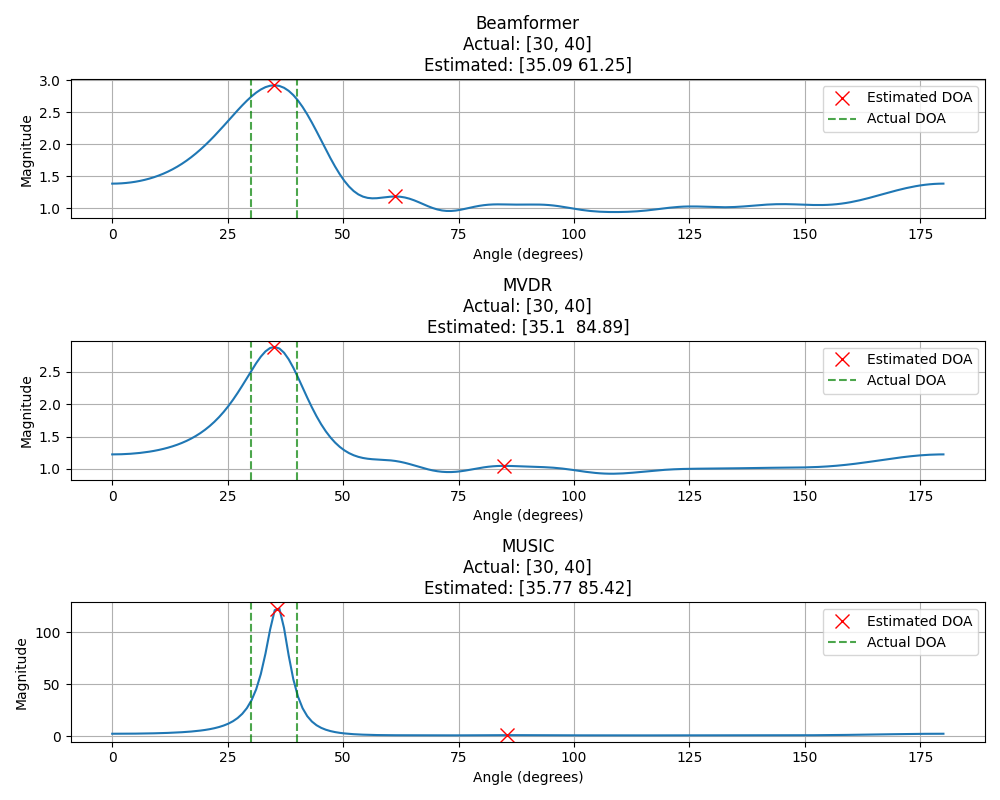

In [17]:
from models.classic import Beamformer, MVDR, MUSIC, RootMUSIC

# Initialize all three estimators
bart = Beamformer(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
mvdr = MVDR(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
music = MUSIC(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
# if array_model.config.array_type == 'linear':
#     rootmusic = RootMUSIC(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
#     num_to_plt = 4
# else:
#     rootmusic = None
#     num_to_plt = 3
num_to_plt = 3
rootmusic = None
# Get actual angles
actual_angles = signal_config.angles
# Create subplots for all three estimators
fig, axes = plt.subplots(num_to_plt, 1, figsize=(10, 8))
if rootmusic is not None:
    estimators = [bart, mvdr, music, rootmusic]
    estimator_names = ['Beamformer', 'MVDR', 'MUSIC', 'RootMUSIC']
else:
    estimators = [bart, mvdr, music]
    estimator_names = ['Beamformer', 'MVDR', 'MUSIC']

for i, (est, name) in enumerate(zip(estimators, estimator_names)):
    # Set received data and estimate DOA
    est.set_received_data(noisy_signal)
    if est == rootmusic:
        estimated_angles, spectrum, doa_predictions_all, roots_angels_all, M = est.estimate_doa()
    else:
        estimated_angles, spectrum = est.estimate_doa()
    
    # Plot the spectrum
    axes[i].plot(angles, spectrum)
    axes[i].set_title(f'{name}\nActual: {actual_angles}\nEstimated: {np.round(estimated_angles, 2)}')
    axes[i].set_xlabel('Angle (degrees)')
    axes[i].set_ylabel('Magnitude')
    axes[i].grid(True)
    
    # Plot estimated angles with X markers
    axes[i].plot(estimated_angles, spectrum[np.searchsorted(angles, estimated_angles)], 
                 'rx', markersize=10, label='Estimated DOA')
    
    # Plot actual angles with dashed lines
    for angle in actual_angles:
        axes[i].axvline(x=angle, color='g', linestyle='--', alpha=0.7, 
                       label='Actual DOA' if angle == actual_angles[0] else "")
    
    axes[i].legend()

plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 5, got 2)

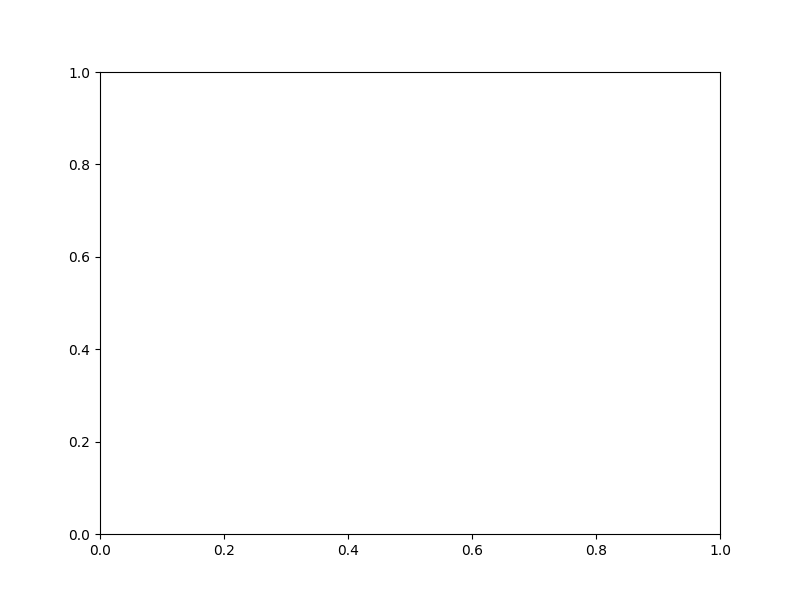

In [18]:
from models.classic import Beamformer, MVDR, MUSIC

# Initialize all three estimators
bart = Beamformer(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
mvdr = MVDR(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
music = MUSIC(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
rootmusic = RootMUSIC(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
est = rootmusic
# Get actual angles
actual_angles = signal_config.angles
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
if est == rootmusic:
    est.set_received_data(noisy_signal)
    doa_predictions, roots, doa_predictions_all, roots_angels_all, M = est.estimate_doa()
    # doa_predictions -= 90
    ax = fig.add_subplot(111, polar=True)
    # Set axis location and limits
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    # ax.set_thetamin(90)
    # ax.set_thetamax(-90)
    # plot roots ang angles 
    for i in range(len(doa_predictions)):
        angle = doa_predictions[i]
        print(angle)
        r = np.abs(doa_predictions[i])
        ax.set_ylim([0, 1.2])
        ax.set_yticks([0, 1])
        ax.plot([0, angle * np.pi / 180], [0, r], marker='o')
    for doa in actual_angles:
        ax.plot([doa * np.pi / 180], [1], marker='x', color="r", markersize=14)
    ax.set_xlabel("Angels [deg]")
    ax.set_ylabel("Amplitude")
    plt.show()
    print(f"RootMUSIC DOA predictions: {doa_predictions}")
else:
    # Set received data and estimate DOA
    est.set_received_data(noisy_signal)
    estimated_angles, spectrum = est.estimate_doa()

    # Plot the spectrum
    ax.plot(angles, spectrum)
    ax.set_title(f'Estimator\nActual: {actual_angles}\nEstimated: {np.round(estimated_angles, 2)}')
    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('Magnitude')
    ax.grid(True)

    # Plot estimated angles with X markers
    ax.plot(estimated_angles, spectrum[np.searchsorted(angles, estimated_angles)], 
            'rx', markersize=10, label='Estimated DOA')

    # Plot actual angles with dashed lines
    for angle in actual_angles:
        ax.axvline(x=angle, color='g', linestyle='--', alpha=0.7, 
                label='Actual DOA' if angle == actual_angles[0] else "")

    ax.legend()
    plt.tight_layout()
    plt.show()


In [13]:
# from models.classic import Beamformer, MVDR, MUSIC

# # Initialize all three estimators
# bart = Beamformer(array_model, A_nominal, angles)
# mvdr = MVDR(array_model, A_nominal, angles)
# music = MUSIC(array_model, A_nominal, angles, num_sources=len(signal_config.angles))
# est = music
# # Get actual angles
# actual_angles = signal_config.angles

# # Create single plot
# fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# # Set received data and estimate DOA
# est.set_received_data(noisy_signal)
# estimated_angles, spectrum = est.estimate_doa()

# # Convert spectrum to dB scale
# spectrum_db = 10 * np.log10(spectrum)

# # Plot the spectrum in dB
# ax.plot(angles, spectrum_db)
# ax.set_title(f'Estimator\nActual: {actual_angles}\nEstimated: {np.round(estimated_angles, 2)}')
# ax.set_xlabel('Angle (degrees)')
# ax.set_ylabel('Magnitude (dB)')
# ax.grid(True)

# # Plot estimated angles with X markers
# ax.plot(estimated_angles, spectrum_db[np.searchsorted(angles, estimated_angles)], 
#          'rx', markersize=10, label='Estimated DOA')

# # Plot actual angles with dashed lines
# for angle in actual_angles:
#     ax.axvline(x=angle, color='g', linestyle='--', alpha=0.7, 
#                label='Actual DOA' if angle == actual_angles[0] else "")

# ax.legend()
# plt.tight_layout()
# plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import h5py
import json
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Import the dataset class
import sys
sys.path.append('../src/data')
from dataset_generator import DOADataset
import visualization
print("Imports successful!")


Imports successful!


In [15]:
DATASET_NAME = "ula_dataset_small"  # Change this to your dataset name
DATASET_PATH = f"../Data/datasets/linear/{DATASET_NAME}/{DATASET_NAME}.h5"

# Load dataset
dataset = DOADataset(DATASET_PATH)

In [56]:
filtered_dataset = dataset.filter(snr=-10, array_imperfections=True, doas=[45], num_sources=[1, 2])
filtered_dataset[1]['received_signal'].shape
idx = 3
print(filtered_dataset[idx]['labels']['doas'])
print(filtered_dataset[idx]['labels']['num_sources'])
print(filtered_dataset[idx]['labels']['num_multipath'])
print(filtered_dataset[idx]['labels']['array_imperfections'])
print(filtered_dataset[idx]['labels']['num_snapshots'])
print(filtered_dataset[idx]['labels']['sir'])
print(filtered_dataset[idx]['labels']['snr'])
print(filtered_dataset[idx]['labels'])
# print(filtered_dataset)
# print(filtered_dataset[0]['labels']['angles_deg'])
# print(filtered_dataset[0]['labels']['frequencies'])
# print(filtered_dataset[0]['labels']['bandwidth'])

[ 45.          32.46308899 171.09883118]
[1 2]
0
True
1024
[0. 0.]
-10.0
{'array_imperfections': True, 'doas': array([ 45.        ,  32.46308899, 171.09883118]), 'num_multipath': 0, 'num_snapshots': 1024, 'num_sources': array([1, 2], dtype=int32), 'sir': array([0., 0.]), 'smr': array([999.]), 'snr': -10.0}


In [57]:
bart = Beamformer(array_model, A_nominal, angles, num_sources=filtered_dataset[0]['labels']['num_sources'].sum())
mvdr = MVDR(array_model, A_nominal, angles, num_sources=filtered_dataset[0]['labels']['num_sources'].sum())
music = MUSIC(array_model, A_nominal, angles, num_sources=filtered_dataset[0]['labels']['num_sources'].sum())
rootmusic = RootMUSIC(array_model, A_nominal, angles, num_sources=filtered_dataset[0]['labels']['num_sources'].sum())

bart.set_received_data(filtered_dataset[idx]['received_signal'])
mvdr.set_received_data(filtered_dataset[idx]['received_signal'])
music.set_received_data(filtered_dataset[idx]['received_signal'])
rootmusic.set_received_data(filtered_dataset[idx]['received_signal'])

estimated_angles_bart, spectrum_bart = bart.estimate_doa()
estimated_angles_mvdr, spectrum_mvdr = mvdr.estimate_doa()
estimated_angles_music, spectrum_music = music.estimate_doa()
estimated_angles_rootmusic, spectrum_rootmusic, doa_predictions_all_rootmusic, roots_angels_all_rootmusic, M_rootmusic = rootmusic.estimate_doa()

print(estimated_angles_bart)
print(estimated_angles_mvdr)
print(estimated_angles_music)
print(estimated_angles_rootmusic)
print(filtered_dataset[idx]['labels']['doas'])


[ 41.22905028  71.39664804 136.75977654]
[ 41.22905028  71.39664804 137.76536313]
[ 40.22346369 137.76536313  69.38547486]
[43.49201215 25.84749208 69.593209  ]
[ 45.          32.46308899 171.09883118]


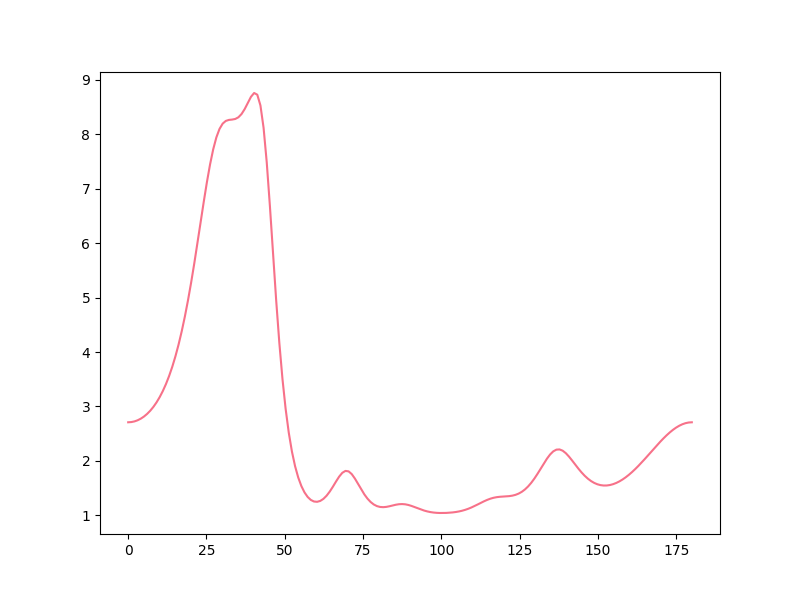

In [58]:
# Plot the spectrum
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(angles, spectrum_music)
# ax.set_title(f'Estimator\nActual: {actual_angles}\nEstimated: {np.round(estimated_angles, 2)}')
# ax.set_xlabel('Angle (degrees)')
# ax.set_ylabel('Magnitude')
# ax.grid(True)

# # Plot estimated angles with X markers
# ax.plot(estimated_angles, spectrum[np.searchsorted(angles, estimated_angles)], 
#         'rx', markersize=10, label='Estimated DOA')

# # Plot actual angles with dashed lines
# for angle in filtered_dataset[0]['labels']['doas']:
#         ax.axvline(x=angle, color='g', linestyle='--', alpha=0.7, 
#                 label='Actual DOA' if angle == actual_angles[0] else "")

# ax.legend()
# plt.tight_layout()
plt.show()